# Demo 1: Exploring Temporal Patterns with Synthetic Healthcare Data

This markdown file is structured for conversion to a Jupyter notebook using Jupytext. Each code cell is marked with triple backticks and `python`, and markdown cells are written as plain text between code cells.

## 1. Setup: Import Libraries and Configure Environment

This section introduces the core Python libraries for data science and time series analysis. Students should recognize these as the "toolkit" for most health data science projects. Setting a random seed ensures reproducibility, which is critical for scientific work.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
import os
from datetime import datetime, timedelta
from lifelines import KaplanMeierFitter, CoxPHFitter

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
os.makedirs('data', exist_ok=True)
os.makedirs('data/synthetic', exist_ok=True)
np.random.seed(42)

## 2. Generate Regular Time Series: Daily Blood Pressure Measurements

This section simulates a year of daily blood pressure readings, including trend, seasonality, weekly patterns, and noise. These are common features in real health data. Students should see how synthetic data can be used to practice analysis before working with sensitive or messy real data.


In [7]:
start_date = datetime(2023, 1, 1)
end_date = datetime(2023, 12, 31)
dates = pd.date_range(start=start_date, end=end_date, freq='D')
baseline = 120
trend_slope = 0.01
seasonal_amplitude = 5
weekly_amplitude = 3
noise_level = 3
n_days = len(dates)
time_index = np.arange(n_days)
trend = baseline + trend_slope * time_index
yearly_cycle = seasonal_amplitude * np.sin(2 * np.pi * time_index / 365)
weekly_cycle = weekly_amplitude * np.array([0, 0, 0, 0, 0.5, 1, 1])[pd.DatetimeIndex(dates).dayofweek]
noise = np.random.normal(0, noise_level, n_days)
systolic_bp = trend + yearly_cycle + weekly_cycle + noise
bp_data = pd.DataFrame({
    'date': dates,
    'systolic_bp': systolic_bp,
    'diastolic_bp': systolic_bp * 0.65 + np.random.normal(0, 2, n_days)
})
bp_data.to_csv('data/synthetic/daily_blood_pressure.csv', index=False)
print("Generated daily blood pressure data with shape:", bp_data.shape)

Generated daily blood pressure data with shape: (365, 3)


### Visualize Blood Pressure Time Series

Visualizing the data helps spot trends, seasonality, and outliers. Line plots are the most common way to view time series. Encourage students to always plot their data before analysis.


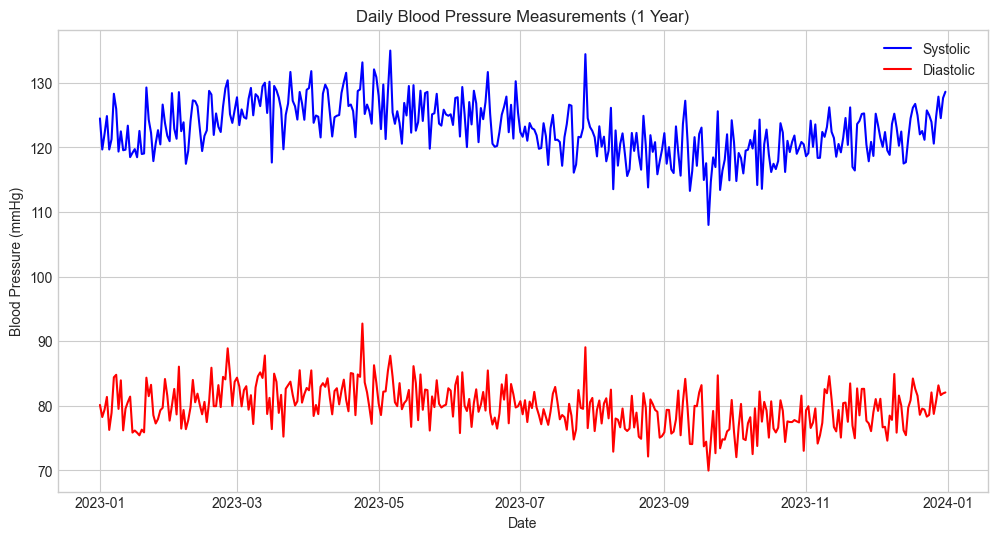

In [8]:
plt.figure(figsize=(12, 6))
plt.plot(bp_data['date'], bp_data['systolic_bp'], 'b-', label='Systolic')
plt.plot(bp_data['date'], bp_data['diastolic_bp'], 'r-', label='Diastolic')
plt.title('Daily Blood Pressure Measurements (1 Year)')
plt.xlabel('Date')
plt.ylabel('Blood Pressure (mmHg)')
plt.legend()
plt.grid(True)
plt.show()

### Decompose Time Series: Trend, Seasonality, Residuals

Decomposition separates a time series into trend, seasonal, and residual components. This is useful for understanding underlying patterns and for forecasting. Students should learn to interpret each component and recognize when decomposition is helpful.


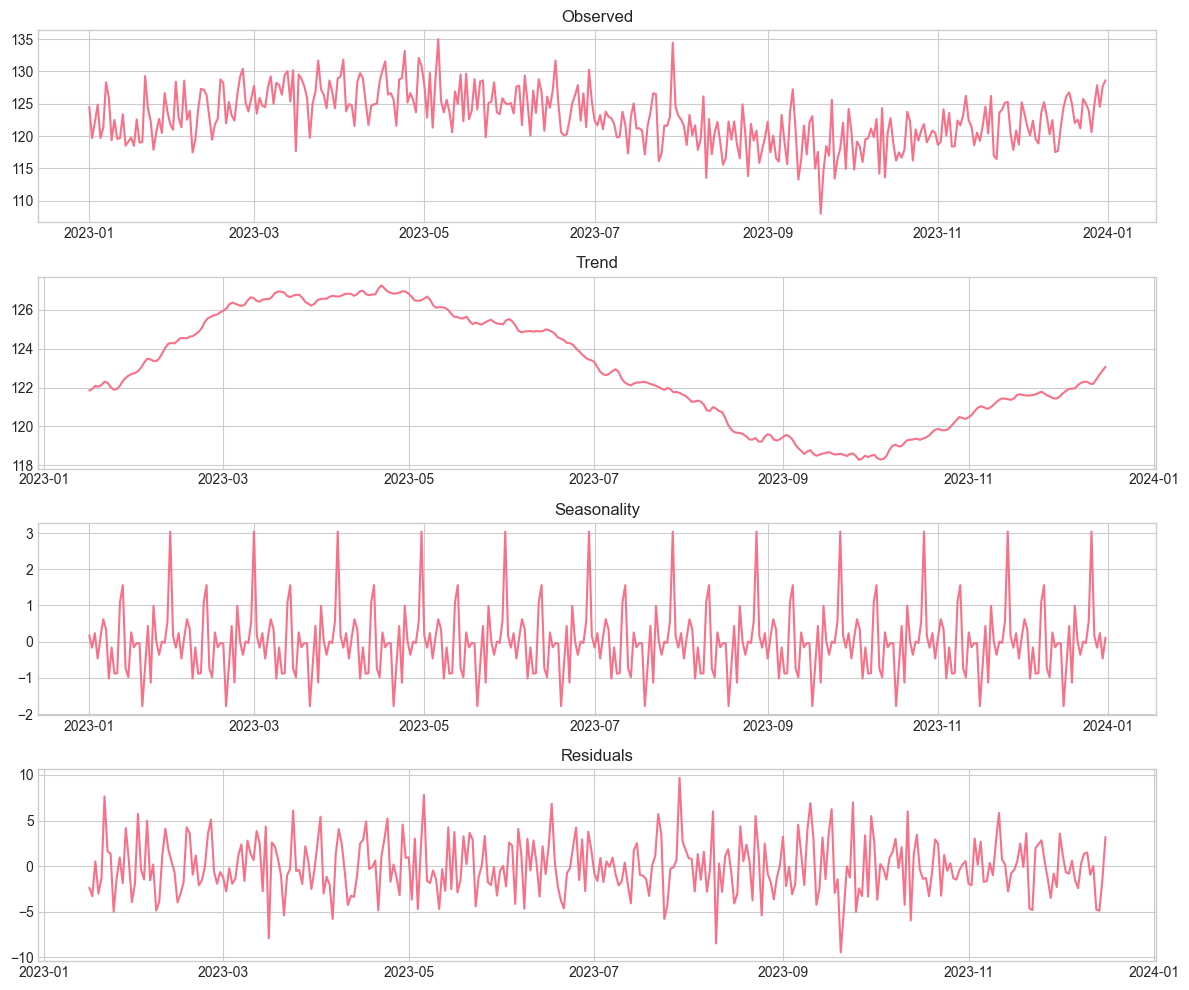

In [9]:
systolic_series = bp_data.set_index('date')['systolic_bp']
decomposition = seasonal_decompose(systolic_series, model='additive', period=30)
plt.figure(figsize=(12, 10))
plt.subplot(4, 1, 1)
plt.plot(decomposition.observed)
plt.title('Observed')
plt.grid(True)
plt.subplot(4, 1, 2)
plt.plot(decomposition.trend)
plt.title('Trend')
plt.grid(True)
plt.subplot(4, 1, 3)
plt.plot(decomposition.seasonal)
plt.title('Seasonality')
plt.grid(True)
plt.subplot(4, 1, 4)
plt.plot(decomposition.resid)
plt.title('Residuals')
plt.grid(True)
plt.tight_layout()
plt.show()

### Weekly and Monthly Pattern Analysis

This section explores how blood pressure varies by day of week and month, which is important for understanding periodic effects in health data. Boxplots are used to visualize distributions across categories. Students should consider how these patterns might affect clinical interpretation or model building.


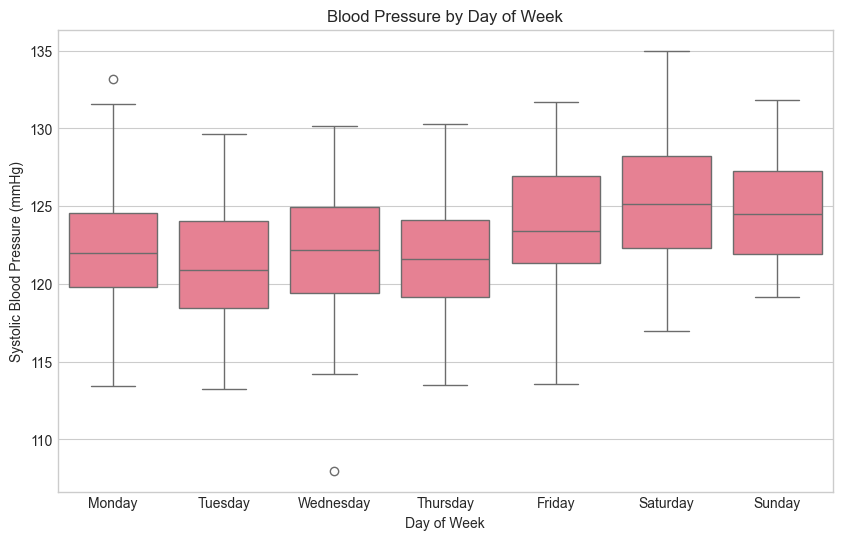

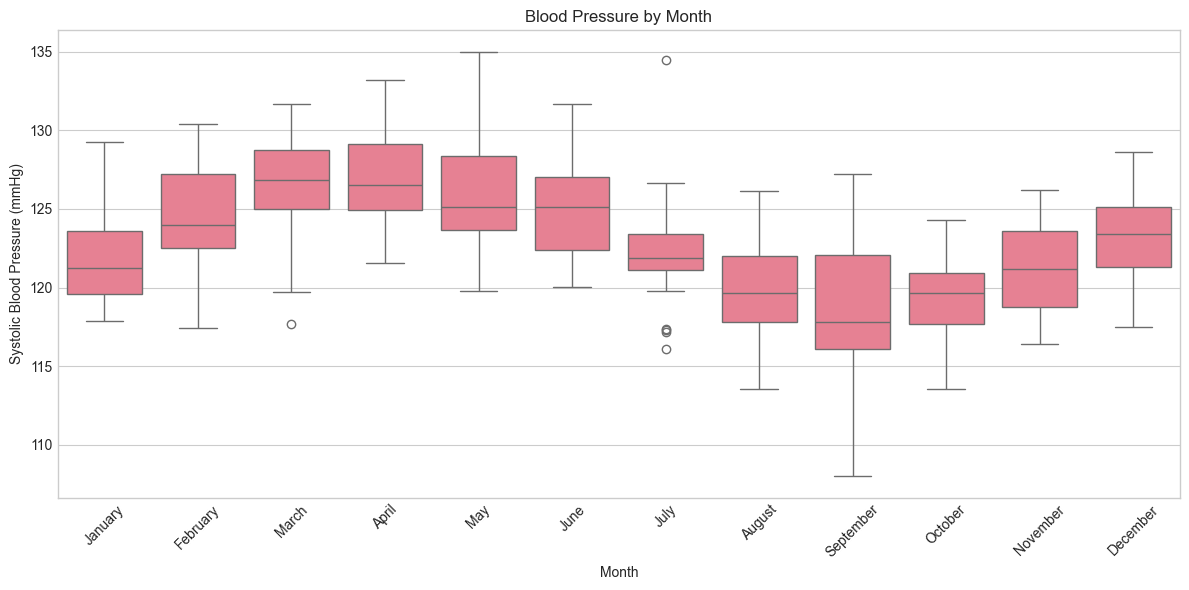

In [10]:
bp_data['day_of_week'] = bp_data['date'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plt.figure(figsize=(10, 6))
sns.boxplot(x='day_of_week', y='systolic_bp', data=bp_data, order=day_order)
plt.title('Blood Pressure by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Systolic Blood Pressure (mmHg)')
plt.grid(True, axis='y')
plt.show()

bp_data['month'] = bp_data['date'].dt.month_name()
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
plt.figure(figsize=(12, 6))
sns.boxplot(x='month', y='systolic_bp', data=bp_data, order=month_order)
plt.title('Blood Pressure by Month')
plt.xlabel('Month')
plt.ylabel('Systolic Blood Pressure (mmHg)')
plt.xticks(rotation=45)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()